# making personalised models (1 model per pp)
gonna use hyperparams from tuning on all pps ('min_samples_leaf': 200, 'max_depth': 500, 'criterion': 'entropy')

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pykalman import KalmanFilter
import os
from sklearn.model_selection import train_test_split , cross_val_score, cross_validate
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [31]:
dir_in = 'D:\\arxeia\\AI_VU\\THESIS_internship\\3-experimental\\data\\allSensors_allPPs'
os.chdir(dir_in)
# df = pd.read_csv('all_data_FINAL.csv')

df = pd.read_csv('all_data_final_kalmanFilled.csv')

In [32]:
num_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer', 'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener', 'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
 'AU14_Dimpler','AU15_LipCornerDepressonr', 'AU17_ChinRaiser', 'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart', 'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
 'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp', 'gazeDown', 'gazeRight', 'gazeLeft', 'duration', 'Rclick', 'Lclick', 'move_dist', 'move_duration', 'move_speed',
 'scroll_dur', 'keyPress', 'press_dur', 'backsp', 'backsp_dur', 'pause_dur', 'pause_rate']

feature_cols = ['AU1_InnerBrowRaiser', 'AU2_OuterBrowRaiser', 'AU4_BrowLowerer', 'AU5_UpperLipRaiser', 'AU6_CheekRaiser', 'AU7_LidTightener', 'AU9_NoseWringler', 'AU10_UpperLipRaiser', 'AU12_LipCornerPuller',
 'AU14_Dimpler','AU15_LipCornerDepressonr', 'AU17_ChinRaiser', 'AU20_LipStretcher', 'AU23_LipTightener', 'AU25_LipsPart', 'AU26_JawDrop', 'AU45_BlinkInt', 'AUc45_BlinkRate', 'AUc28_LipSuck',
 'headOrient_x', 'headOrient_y', 'headOrient_z', 'gazeCenter', 'gazeUp', 'gazeDown', 'gazeRight', 'gazeLeft', 'Rclick', 'Lclick', 'keyPress', 'move_dist','move_duration']

# feature_cols = num_cols

In [33]:
#creating ordered list of all pps
pp_lst = list(set(df['pp_id']))
pp_lst.sort()
pp_lst


['pp02',
 'pp03',
 'pp04',
 'pp05',
 'pp06',
 'pp07',
 'pp09',
 'pp11',
 'pp12',
 'pp13',
 'pp15',
 'pp16',
 'pp17',
 'pp18',
 'pp19',
 'pp22',
 'pp23',
 'pp24',
 'pp25',
 'pp26']

# creating function that cv & trains of full data

In [176]:

def run_cv_dt (df):
    print('making model for pp '+str(set(df['pp_id'])))
    #1st split data
    x_train, x_test, y_train, y_test = train_test_split(df[feature_cols], df['condition'],  test_size=0.20, random_state=42)

    #scale
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    #using hyperparams of model tuned on all pps
    # model = DecisionTreeClassifier(min_samples_leaf=200, max_depth=500, criterion='entropy',  random_state=42 )
    model = DecisionTreeClassifier( random_state=42 )
# 

    cv_scores = cross_val_score(model, x_train_scaled, y_train,  scoring='accuracy', cv=5) 

    print('cross val scores: {}'.format(scores))

    #then can train on full data & check performance on test set (never seen before). 
    print('now training on full data and predicting on test set(never seen before)DOING THIS ONLY ONCE!')
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    print('\n classification  report on full data (run only once!)')
    print(classification_report(y_test, y_pred))
    test_acc =accuracy_score(y_test, y_pred)

    return model, cv_scores, test_acc

In [177]:
#looping opver pps
pp_models_lst=[] ; pp_train_scores=[] ; pp_test_acc=[]
for pp in pp_lst:
    curr_df = df.loc[df['pp_id']==pp].reset_index().copy()
    curr_model, curr_cv_scores, curr_test_acc = run_cv_dt(curr_df)
    pp_models_lst.append(curr_model)
    pp_train_scores.append(curr_cv_scores)
    pp_test_acc.append(curr_test_acc)


making model for pp {'pp02'}
cross val scores: [0.5        0.5        0.6        0.55555556 0.55555556]
now training on full data and predicting on test set(never seen before)DOING THIS ONLY ONCE!

 classification  report on full data (run only once!)
              precision    recall  f1-score   support

           N       1.00      1.00      1.00         4
           S       1.00      1.00      1.00         8

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

making model for pp {'pp03'}
cross val scores: [0.5        0.5        0.6        0.55555556 0.55555556]
now training on full data and predicting on test set(never seen before)DOING THIS ONLY ONCE!

 classification  report on full data (run only once!)
              precision    recall  f1-score   support

           N       0.75      0.75      0.75         4
           S       0.88      0.88      0.88         8

    a

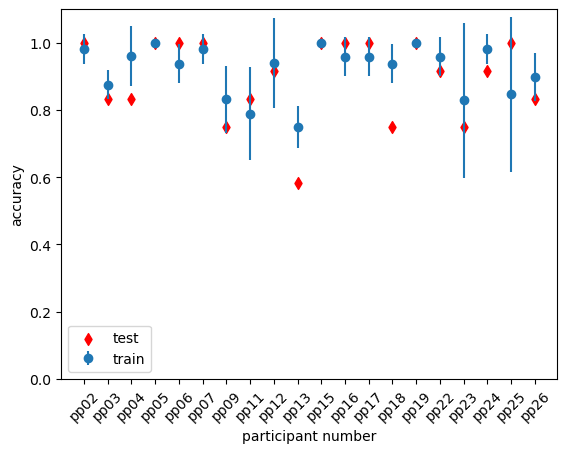

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import stdev

res_df = pd.DataFrame()
res_df['pp_id'] = pp_lst
res_df['mean_train_acc'] = [x.mean() for x in pp_train_scores]
res_df['std_train_acc']= [stdev(x) for x in pp_train_scores]
res_df['test_acc'] = pp_test_acc

ax=plt.subplot(111)
plt.errorbar(x= res_df.index, y= res_df['mean_train_acc'], yerr=res_df['std_train_acc'], fmt="o", label ='train')
plt.scatter(res_df.index, res_df['test_acc'], marker = 'd', color='red', label='test')
ax.set_xticks( ticks= res_df.index, labels= res_df['pp_id'], rotation=45)
ax.set_ylim(0, 1.1)
plt.xlabel('participant number')
plt.ylabel('accuracy')
plt.legend()

In [86]:
for i in range(len(pp_scores)):
    print()
    print('train')
    print(pp_train_scores[i].mean())
    print('test')
    print(pp_test_acc[i])



train
0.9800000000000001
test
1.0

train
0.7488888888888889
test
0.0

train
0.8577777777777778
test
0.9166666666666666

train
1.0
test
1.0

train
0.9
test
1.0

train
0.9355555555555555
test
1.0

train
0.7977777777777777
test
0.0

train
0.6044444444444445
test
0.6666666666666666

train
0.8800000000000001
test
0.5833333333333334

train
0.5
test
0.08333333333333333

train
0.9800000000000001
test
1.0

train
0.96
test
0.9166666666666666

train
0.7955555555555556
test
1.0

train
0.8800000000000001
test
0.5

train
0.8511111111111112
test
0.0

train
0.8355555555555554
test
0.75

train
0.47777777777777775
test
0.9166666666666666

train
0.9400000000000001
test
0.8333333333333334

train
0.7177777777777778
test
0.8333333333333334

train
0.7822222222222222
test
0.6666666666666666
